# CoexpressDeconvolve
#### Automated Visium Standard Definition Spatial Transcriptomics data deconvolution

In [1]:
# %pip install h5py tqdm

In [4]:
import codeconv
import os

In [5]:
visium_path = "." 
output_folder = "."
config_path = "codeconv_config.json"

Step 1: Checking data format in ....
   > Found Matrix directory: ./filtered_feature_bc_matrix. Loading MTX...

LIBRARY DEPTH QC
Median UMI per Spot: 226
Mean UMI per Spot:   1065
1th Percentile:      24


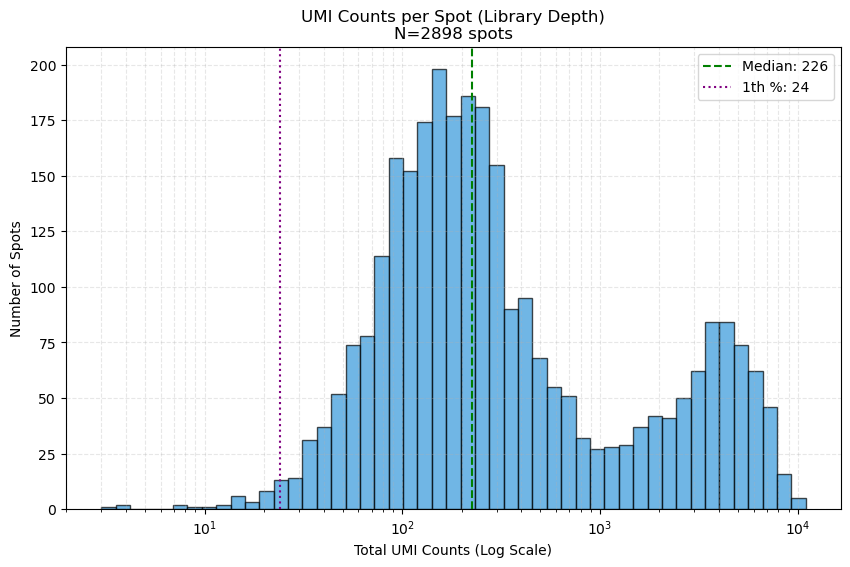

Step 1 took 0.338470 seconds


In [6]:
# STEP 1: LOAD
raw_counts, gene_names, barcodes, coords, total_umi, scales = codeconv.step1_acquisition_and_anchoring(visium_path)

In [7]:
# Mouse gene name fix
upper_gene_names = [item.upper() for item in gene_names]

Step 2: Loading Single Cell Standard from codeconv_config.json...
Step 2: Using 10 HK genes for calibration.


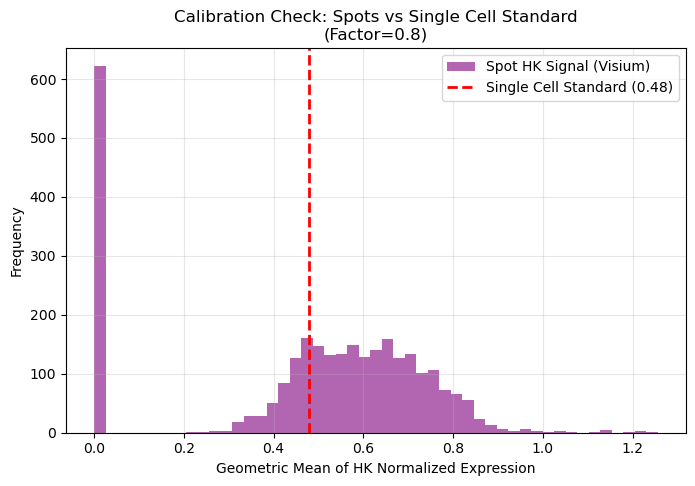

   > Single Cell Standard is: 0.48

FILTERING REPORT
Total Empty Spots (0 cells): 643 / 2898 (22.2%)
Among them are those with low UMI content: 19


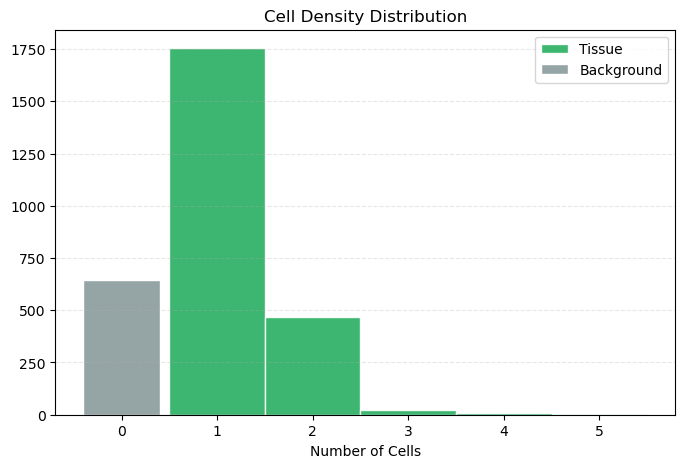

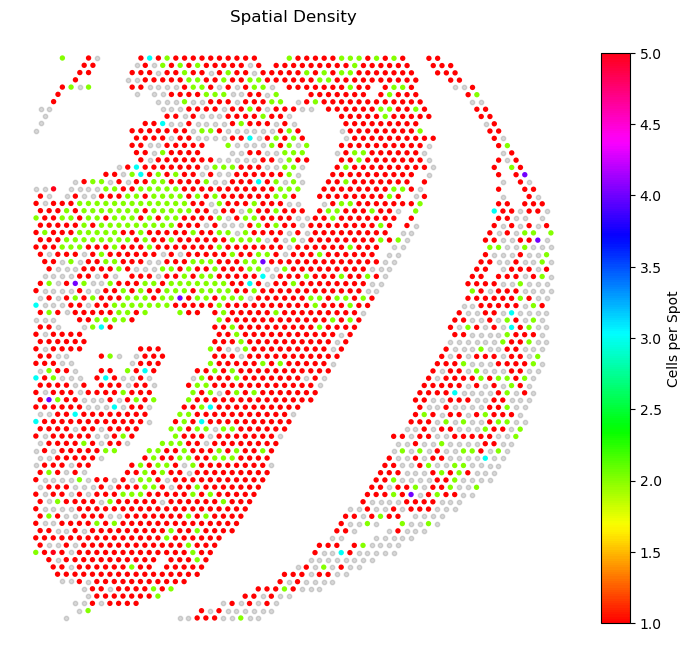


The number of cells on the Visium slide is 2799.
Step 2 took 0.223551 seconds


In [8]:
# STEP 2: DENSITY
n_cells_per_spot, engine_params = codeconv.step2_estimate_cell_density(
    raw_counts, 
    upper_gene_names, 
    total_umi, 
    coords, 
    config_path,
    min_umi=20, 
    anchor_mean_factor=0.8, # adjust this factor to align the red line with the first non-zero peak on the graph
    colormap='hsv'
)

Step 3: Filtering transcriptome (Species: mm)...
   - Removed 416 noise genes.
   - Remaining feature space: 19049 genes.
Step 3: Selecting top 2000 HVGs for Model Training...


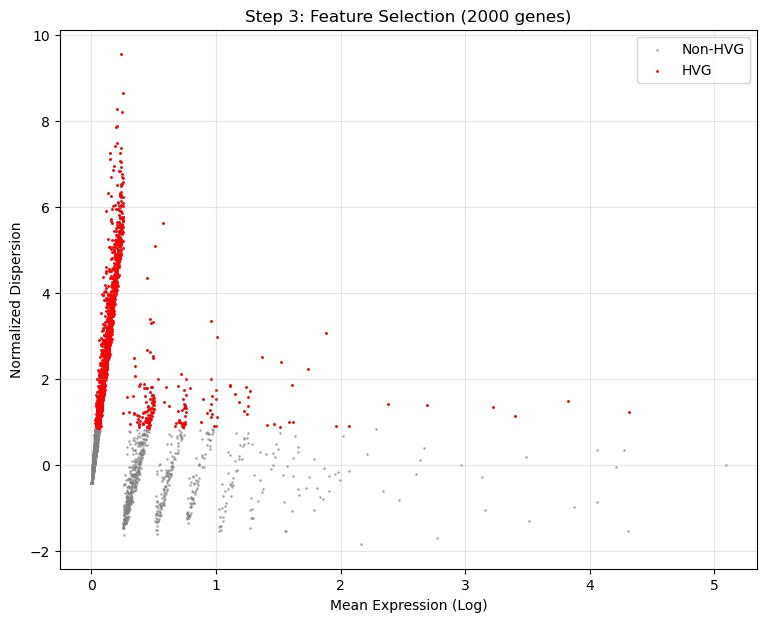

Step 3 Complete. Training set shape: (2898, 2000)
Step 3 took 0.140748 seconds


In [9]:
# STEP 3: Cleanup & Select HVGs
counts_clean, genes_clean, hvg_data, hvg_names = codeconv.step3_feature_selection(
    raw_counts, gene_names,
    species='mm', # 'hs' / 'mm'
    n_hvg=2000
)

Step 4: Constructing Gene Manifold for 19049 genes...
   - Preprocessing: Log-transformation and Scaling...
   - Decomposition: FastICA (30 components)...
   - Topology: UMAP Projection (Metric: Cosine)...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


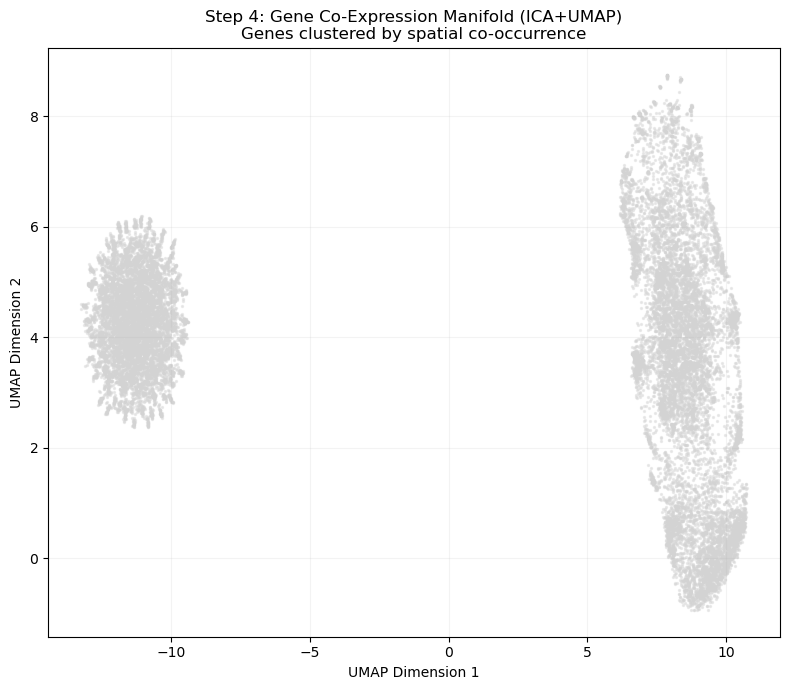

Step 4 took 54.373431 seconds


In [10]:
# STEP 4: Construct Gene Coexpression Manifold
embedding, reducer = codeconv.step4_gene_manifold(
    counts_clean, genes_clean, n_components = 30
)

In [ ]:
# STEP 5: K optimization

codeconv.step5_ksweep(hvg_data, min_k=3, max_k=20, step=1, subsample_frac=1,
                      doc_topic_prior=0.1,topic_word_prior=0.01)

In [11]:
# STEP 6: Final LDA Model & Manifold-Guided Projection

SELECTED_K = 11 

print(f"Starting Step 6 with K={SELECTED_K}...")

theta, beta_final, qc_df = codeconv.step6_final_deconvolution(
    hvg_data,      
    counts_clean,  
    genes_clean,
    hvg_names,
    n_topics=SELECTED_K,
    embedding=embedding,
    n_iters=30,
    k_neighbors=3,       # Nearest neighbors on the UMAP map
    min_sim=0.05,         # Minimum cosine expression similarity threshold
    doc_topic_prior=0.1,
    topic_word_prior=0.01
)

print("Top markers per topic:")
display(qc_df)

Starting Step 6 with K=11...
Step 6: Training Final LDA Model with chosen K=11...
iteration: 1 of max_iter: 30
iteration: 2 of max_iter: 30
iteration: 3 of max_iter: 30
iteration: 4 of max_iter: 30
iteration: 5 of max_iter: 30
iteration: 6 of max_iter: 30
iteration: 7 of max_iter: 30
iteration: 8 of max_iter: 30
iteration: 9 of max_iter: 30
iteration: 10 of max_iter: 30
iteration: 11 of max_iter: 30
iteration: 12 of max_iter: 30
iteration: 13 of max_iter: 30
iteration: 14 of max_iter: 30
iteration: 15 of max_iter: 30
iteration: 16 of max_iter: 30
iteration: 17 of max_iter: 30
iteration: 18 of max_iter: 30
iteration: 19 of max_iter: 30
iteration: 20 of max_iter: 30
iteration: 21 of max_iter: 30
iteration: 22 of max_iter: 30
iteration: 23 of max_iter: 30
iteration: 24 of max_iter: 30
iteration: 25 of max_iter: 30
iteration: 26 of max_iter: 30
iteration: 27 of max_iter: 30
iteration: 28 of max_iter: 30
iteration: 29 of max_iter: 30
iteration: 30 of max_iter: 30
Step 6: Projecting latent t

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10
0,Robo3,Prl8a9,Nkx3-2,Lor,Ermap,Fam167b,Fam107b,Otp,Klhdc8b,Abca3,Lhx2
1,Ascl1,Serpine1,Hmx1,Grin2d,Cited4,Kdf1,Prrxl1,Shank3,Mt3,Cracr2b,Lhx1
2,Adgrg1,Prl3b1,Matn4,Vwa5b2,Fabp5,Cideb,Cyb561,Mettl25,Cfap44,Cys1,Pou4f1
3,Zfp777,Fthl17a,Jph2,Fbxo41,Ambp,Ankra2,Cdc7,Hoxc4,Fgfbp3,Nrtn,Lbx1
4,Phf21b,Tfpi,Pias4,Ggt7,Hspd1,Myo1e,Csk,Hoxc9,Trabd2b,Tmc4,Pde11a
5,Nup54,Prl7a2,Ntrk1,Ahi1,Slc16a6,Uap1l1,Ash1l,Cep170b,Rgma,Prap1,Arpp21
6,Pi4ka,Rhox9,Mybph,Vstm2a,Mbtd1,Spint1,Zfp618,Osbp2,Mid1ip1,C3,Runx1t1
7,Ubp1,Tpbpb,Fgf5,Pou3f1,Rtn3,Dcxr,Acly,Ppargc1b,Shh,Guca2b,Epha8
8,Psme1,Sct,Klhl31,Chsy3,Alms1,Palm3,Brd3,Nr2c2ap,Ppt2,Pgr,Pax2
9,Neurod6,Prl2a1,Chrng,Hcn4,Hbb-bt,Amn,Lmo4,Vat1l,Rapgef3,Lrrc3,Cep170


In [12]:
# STEP 7: Generate deconvolved in silico single cells

final_matrix, cell_metadata = codeconv.step7_sampling_engine(
    counts_clean, n_cells_per_spot, theta, beta_final, engine_params
)

Step 7: initializing Sampling Engine...


Generating Single Cells:   0%|          | 0/2898 [00:00<?, ?spot/s]


   > Generated 2799 single cells total.
Step 7 Complete.
Step 7 took 5.401862 seconds


In [13]:
# STEP 8: Place the deconvolved in silico single cells back on slide
final_bcs, final_coords = codeconv.step8_geometry_and_placement(
    cell_metadata, coords, barcodes, scales
)

# STEP 9:10X file format export (h5 + spatial)
codeconv.step9_export_results(
    output_folder, final_matrix, genes_clean, final_bcs, final_coords, 
    os.path.join(visium_path, "spatial")
)

   > Calculating Fibonacci shell positions...
Step 8 Complete.
Step 8 took 0.006870 seconds
Step 9: Exporting data to ./deconvolved ...
   > Writing HDF5 matrix to ./deconvolved/filtered_feature_bc_matrix.h5...
Step 9 Complete. Output is ready for Seurat::Load10X_Spatial().
Step 9 took 0.031376 seconds
